# Heart Attack Risk Prediction

## Project Overview
This notebook predicts whether a patient has a low or high chance of a heart attack based on clinical features.

We build and evaluate four classification models:
1. K-Nearest Neighbors (KNN)
2. Decision Tree Classifier
3. Logistic Regression
4. Support Vector Machine (SVM)

Finally, we compare model performances using Accuracy, Precision, Recall, and F1-Score to select the best model.

### 📦 Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set visual style
sns.set_theme(style="whitegrid")

## 1. Load Data & Exploratory Data Analysis (EDA)
Load the `heart.csv` dataset, check basic statistics, missing values, and duplicate rows.

In [2]:
# Load dataset
df = pd.read_csv('heart.csv')

# View dataset dimensions and preview
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# Summary statistics and info
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed successfully.")

Dataset Shape: (303, 14)

First 5 rows:
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol 

## 2. Data Preprocessing & Feature Scaling
Separate independent features ($X$) and target ($y$), split into train/test sets, and scale numerical variables using `StandardScaler`.

In [10]:
# Separate features and target
X = df.drop('output', axis=1)
y = df['output']

# Split data: 80% Training, 20% Testing (stratified by target class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Model Building & Training
Train Logistic Regression, KNN, Decision Tree, and SVM classifiers on the scaled training dataset.

In [11]:
# Initialize algorithms
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

# Dictionary to store performance metrics
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Store results
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Confusion Matrix': cm,
        'Model Object': model
    }

## 4. Model Evaluation & Comparison
Compare classification metrics across all trained models and visualize their confusion matrices.

--- Model Performance Comparison ---
                     Accuracy Precision    Recall  F1-Score
Logistic Regression  0.786885  0.763158  0.878788  0.816901
KNN                  0.803279  0.769231  0.909091  0.833333
Decision Tree        0.721311  0.710526  0.818182  0.760563
SVM                  0.836066  0.794872  0.939394  0.861111


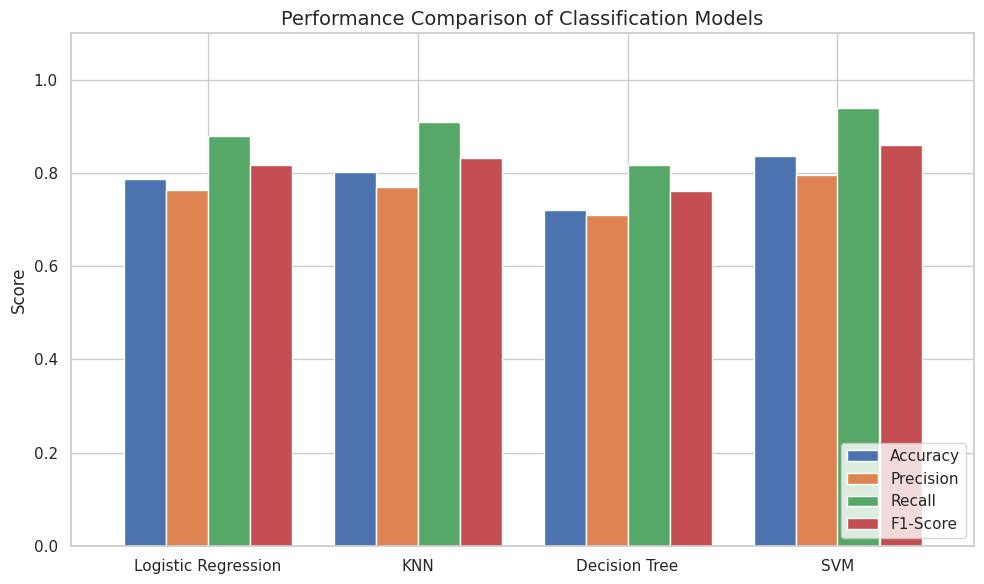

----------------------------------------------------------------------------------------------------


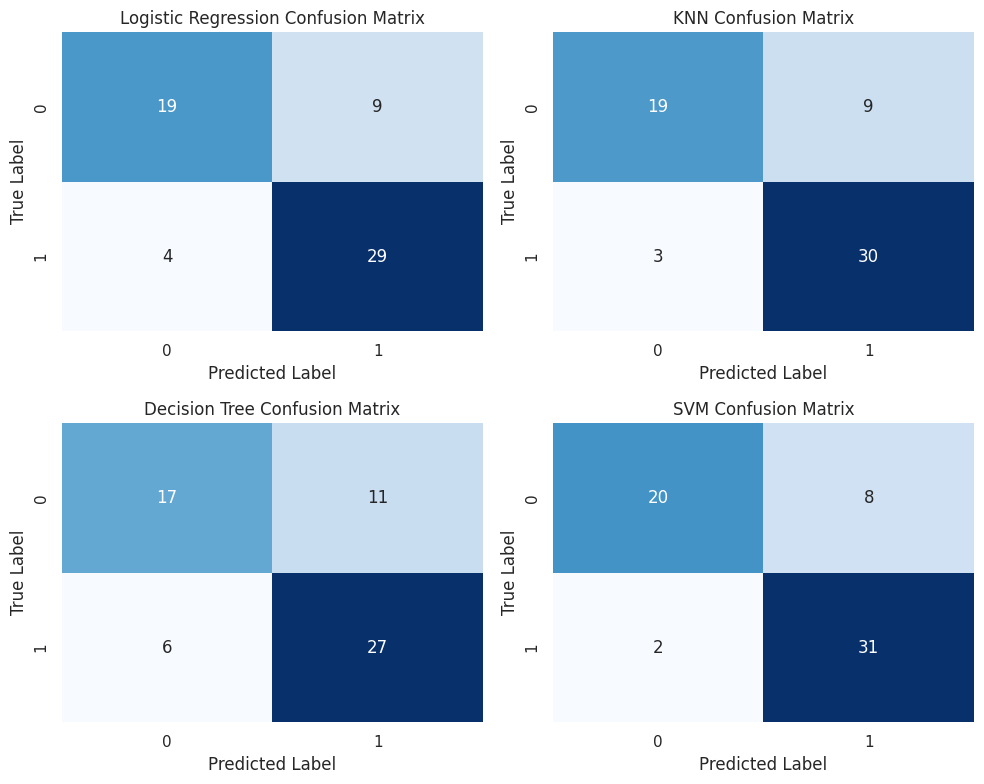

In [18]:
# Convert evaluation metrics into a readable DataFrame
results_df = pd.DataFrame(results).T.drop(columns=['Confusion Matrix', 'Model Object'])
print("--- Model Performance Comparison ---")
print(results_df.round(4))

# Plot evaluation metrics bar chart
ax = results_df.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.title('Performance Comparison of Classification Models', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("-"*100)

# Plot Confusion Matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (name, metrics) in enumerate(results.items()):
    sns.heatmap(metrics['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## 5. Best Model Selection & Export
Identify the top model based on F1-Score and export both the trained model and scaler for deployment.

In [19]:
# Identify best model using F1-Score
best_model_name = results_df['F1-Score'].astype(float).idxmax()
best_model = results[best_model_name]['Model Object']

print(f"Top Performing Model: {best_model_name}")
print(f"F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")

# Save the best model and scaler to disk
joblib.dump(best_model, 'best_heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\nModel artifact ('best_heart_disease_model.pkl') and scaler ('scaler.pkl') saved successfully!")

Top Performing Model: SVM
F1-Score: 0.8611

Model artifact ('best_heart_disease_model.pkl') and scaler ('scaler.pkl') saved successfully!


---
*I built these models while learning machine learning :)*

***Follow me on GitHub: [Tony White](https://github.com/itstonywhite) ✍️***
